# Simple Liner Regression

# Data

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [90]:
from sklearn.datasets import make_regression
import pandas as pd

X, y = make_regression(
    n_samples=200,
    n_features=1,
    n_informative=1,
    noise=20,
    random_state=42
)


In [91]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

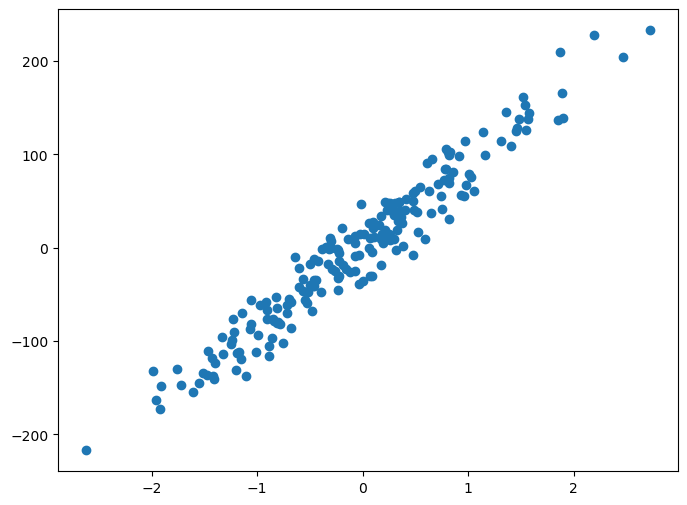

In [92]:
plt.figure(figsize=(8,6))
plt.style.use('default')
plt.scatter(X,y)

In [93]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
pred_sk = lr.predict(X_train)

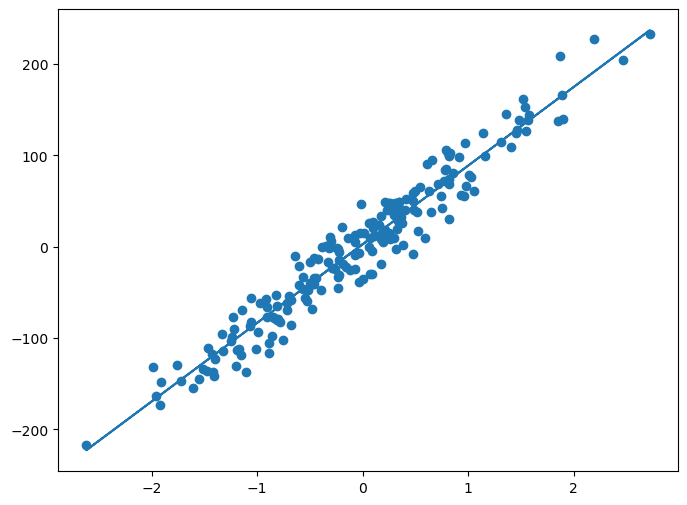

In [94]:
plt.figure(figsize=(8,6))
plt.plot(X_train,pred_sk)
plt.style.use('default')
plt.scatter(X,y)

In [95]:
class Lr:
    def __init__(self):
        self.m = None
        self.b = None
    def fit(self,X,y):
        x_bar = np.mean(X)
        y_bar = np.mean(y)
        num = 0
        den = 0
        for i in range(X.shape[0]):
            num += (X[i] - x_bar)*(y[i] - y_bar)
            den += (X[i] - x_bar)**2
        self.m = num / den
        self.b = self.m*x_bar - y_bar
    def predict(self, X):
        y = []
        for x in X:
            y.append((self.m*x + self.b))
        return y

In [96]:
model = Lr()
model.fit(X_train,y_train)
pred = model.predict(X_test)

In [97]:
pred = np.array(pred).ravel()

In [98]:
print(pred.shape)

(40,)


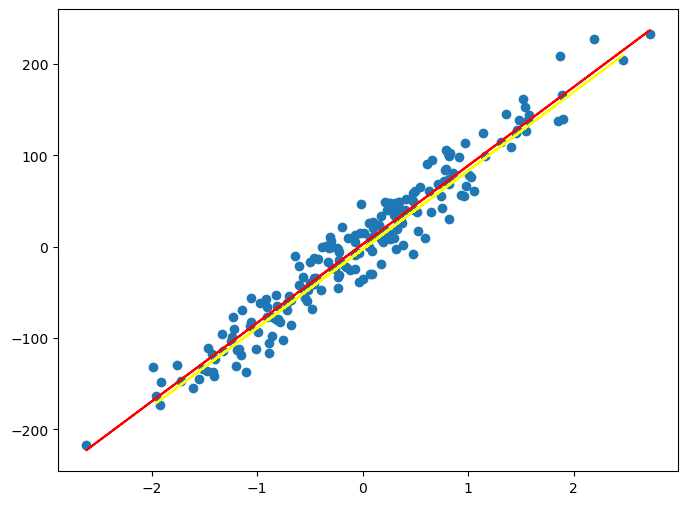

In [99]:
plt.figure(figsize=(8,6))
plt.plot(X_test,pred,color='yellow')
plt.plot(X_train,pred_sk,color='red')
plt.style.use('default')
plt.scatter(X,y)

# Mupltiple Liner Regression

In [100]:
from sklearn.datasets import make_regression

X,y = make_regression(
    n_samples= 200,
    n_features= 2,
    n_informative=2,
    n_targets=1,
    noise=20,
    random_state=42
)

In [101]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y)

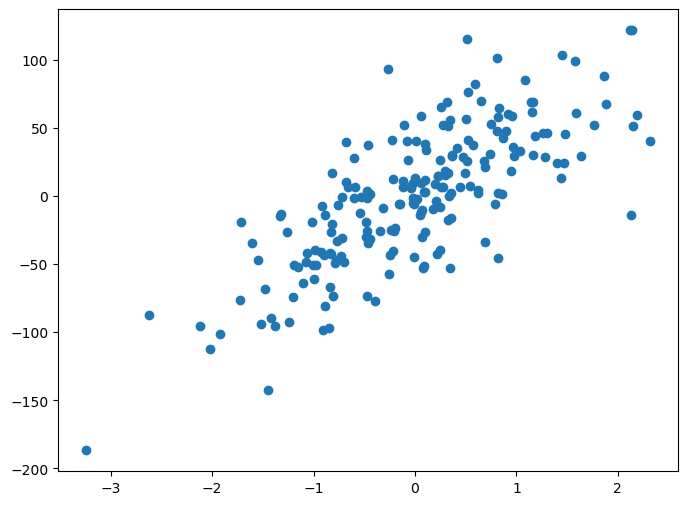

In [102]:
plt.figure(figsize=(8,6))
plt.style.use('default')
plt.scatter(X[:,0],y)

In [103]:
class mLR():
    def __init__(self):
        self.beta = None
        self.intercept_ = None
        self.coef_ = None
    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1)
        self.beta = np.dot(np.linalg.inv(np.dot(X_train.T,X_train)),np.dot(X_train.T,y_train))
        self.coef_ = self.beta[0]
        self.intercept_ = self.beta[1:]
    def predict(self,X_test):
        X_test = np.insert(X_test,0,1,axis=1)
        return np.dot(X_test,self.beta)

In [104]:
model = mLR()

In [105]:
model.fit(X_train,y_train)

In [106]:
pred = model.predict(X_test)

## Regression Metrics

Metrics help us evaluate the performance of a machine learning model.

Metrics are things by which we can determine performance of our model.

### R2 Score
- R2 Score is the main metric.
- It tells how good our model is compared to the worst case.
- If we predict just the average value (`y_bar`), that is like a baseline.
- Formula:

`r2_score = 1 - (y_pred / y_bar)`

### Adjusted R2 Score
- This is a better version of R2 Score.
- It also considers the number of columns/features.
- Formula:

`1 - ( (1 - r2_score) * (n - 1) / (n - k - 1) )`

Where:
- `k` = number of columns
- `n` = number of rows

### MAE
- MAE means `mean_absolute_error`
- It is the average of `abs(y - y_pred)`
- It is easy to understand
- We can directly see error in same ratio/unit
- Example: if prediction is for money, we can say prediction has `100 Rs` average error

### MSE
- In MSE we use square instead of absolute value
- It is differentiable, so it can be improved by model training
- But it is highly affected by outliers
- Also, we cannot compare its value directly because it is squared

### RMSE
- If we do root of MSE, it is called RMSE
- It brings the error back to the original unit
- But it still has the problem of outliers

### MAE vs MSE
- MAE is easy to understand
- MAE is less affected by outliers
- But absolute value is not differentiable at zero

- MSE is differentiable
- So it is better for optimization
- But it is more sensitive to outliers

In [108]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
r2 = r2_score(y_test,pred)
MAE = mean_absolute_error(y_test,pred)
MSE = mean_squared_error(y_test,pred)

In [110]:
print(f'r2 :{r2}')
print(f'MAE :{MAE}')
print(f'MSE :{MSE}')
print(f'RMSE :{np.sqrt(MSE)}')

r2 :0.8815289045953911
MAE :15.62057341073111
MSE :409.95848858725424
RMSE :20.24743165409515


In [111]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)

In [112]:
print(r2_score(y_test,pred))

0.8815289045953911


# Improvement Notes
In sklearn LinerRegression loss function is calculated as show in this code with `np.linalg.inv(np.dot(X_train.T,X_train))` in loss function Basically, `1 / (X.T * X)`. <br>
But it can be very heavy on computer for big data, so we use Gradient instead for normal differentiation.

### SGDRegressor
`SGDRegressior()` which is another model uses gradient instead of this, but normal LinerRegression works like we learned.

### PolynomialFeatures
if our data is in shape of curve we can use polynomial regressor to predict with model called `PolynomialFeatures` we wont be going to deep into those two for now sines we have more models that we can use to do all those.
